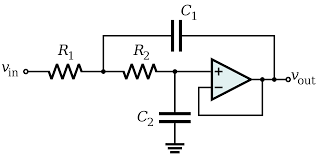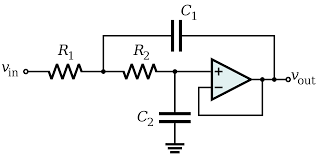

In [87]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from control import matlab as mat

In [88]:
Vx,Vi,Vo,R1,R2,C1,C2,S=sp.symbols("Vx,Vi,Vo,R1,R2,C1,C2,S")

$i_f=i_1+i_2$

In [89]:
i_f=(Vo-Vx)*S*C1
i_f

C1*S*(Vo - Vx)

In [90]:
i_1=(Vx-Vi)/R1
i_1

(-Vi + Vx)/R1

In [91]:
i_2=Vo*S*C2
i_2

C2*S*Vo

#current through C2 and R2 is equal 

$\therefore$ $\frac{Vx-Vo}{R1}=V_oSC2$

In [93]:
eq=sp.Eq((Vx-Vo)/R2,Vo*S*C2)
eq

Eq((-Vo + Vx)/R2, C2*S*Vo)

solving for $V_x$

In [ ]:
sol=sp.solve(eq,Vx)
sol[0]

[Vo*(C2*R2*S + 1)]

In [95]:
#subtitue into the main equation
main_eq=sp.Eq(i_f,i_1+i_2)
main_eq

Eq(C1*S*(Vo - Vx), C2*S*Vo + (-Vi + Vx)/R1)

In [96]:
main_eq=main_eq.subs(Vx,sol[0])
main_eq

Eq(C1*S*(-Vo*(C2*R2*S + 1) + Vo), C2*S*Vo + (-Vi + Vo*(C2*R2*S + 1))/R1)

In [97]:
solution=sp.solve(main_eq,Vo)

In [106]:
H=sp.simplify(solution[0]/Vi)

H

1/(C1*C2*R1*R2*S**2 + C2*R1*S + C2*R2*S + 1)

In [107]:
#let the value of C1=C2=R1=R2=1

params={
    "C1":1,
    "C2":1,
    "R1":1,
    "R2":1
}

In [108]:
params

{'C1': 1, 'C2': 1, 'R1': 1, 'R2': 1}

In [112]:
print(f"Transfer Function: ")
H.subs(params)

Transfer Function: 


1/(S**2 + 2*S + 1)

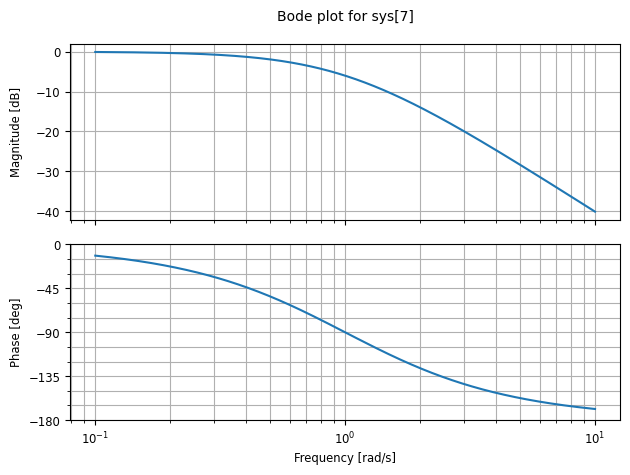

In [134]:
sys=mt.tf([1],[1,2,1])
mag,phase,omega=mt.bode(sys)